In [3]:
import pandas as pd

lecture = pd.read_parquet("flights.parquet", engine="fastparquet")
lecture


,FL_DATE,DEP_DELAY,ARR_DELAY,AIR_TIME,DISTANCE,DEP_TIME,ARR_TIME
0,2006-01-01,5,19,350,2475,9.083333,12.483334
1,2006-01-02,167,216,343,2475,11.783334,15.766666
2,2006-01-03,-7,-2,344,2475,8.883333,12.133333
3,2006-01-04,-5,-13,331,2475,8.916667,11.950000
4,2006-01-05,-3,-17,321,2475,8.950000,11.883333
...,...,...,...,...,...,...,...
999995,2006-02-20,87,86,71,545,19.733334,21.333334
999996,2006-02-20,-2,0,71,508,8.050000,9.583333
999997,2006-02-20,33,19,64,508,14.700000,15.983334
999998,2006-02-20,65,54,65,508,17.633333,18.983334


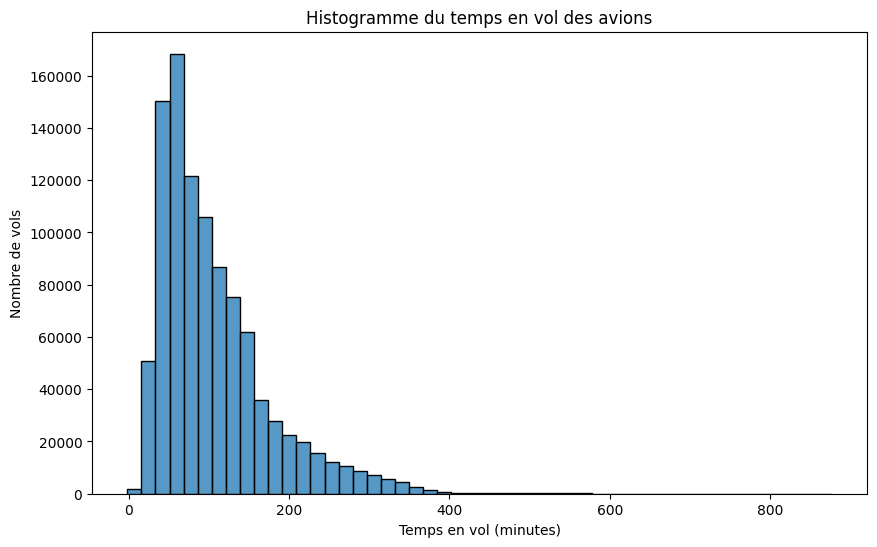

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


graph = pd.read_parquet("flights.parquet", engine="fastparquet")


plt.figure(figsize=(10,6))
sns.histplot(graph['AIR_TIME'], bins=50, kde=False)
plt.title("Histogramme du temps en vol des avions")
plt.xlabel("Temps en vol (minutes)")
plt.ylabel("Nombre de vols")
plt.show()


Variance initiale : 4807.528071807972
Variance après log et suppression des valeurs <= 0 : 0.3829709


/var/folders/f9/r4vpt9g94nxb3jd20qsyy8lc0000gn/T/ipykernel_37618/4079660889.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flights_copy['AIR_TIME_LOG'] = np.log(flights_copy['AIR_TIME'])


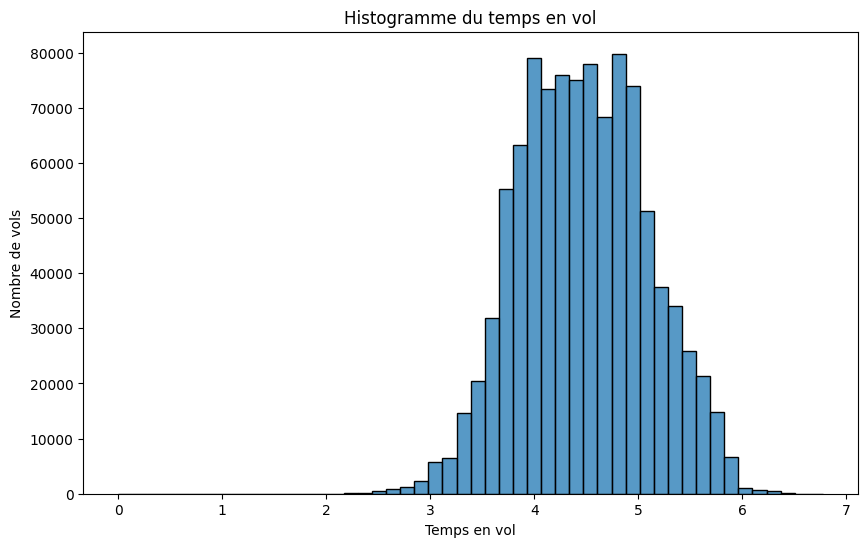

In [9]:
import numpy as np


filtre = graph.copy()
print("Variance initiale :", filtre['AIR_TIME'].var())
flights_copy = filtre[filtre['AIR_TIME'] > 0]

flights_copy['AIR_TIME_LOG'] = np.log(flights_copy['AIR_TIME'])

print("Variance après log et suppression des valeurs <= 0 :", flights_copy['AIR_TIME_LOG'].var())

plt.figure(figsize=(10,6))
sns.histplot(flights_copy['AIR_TIME_LOG'], bins=50, kde=False)
plt.title("Histogramme du temps en vol")
plt.xlabel("Temps en vol")
plt.ylabel("Nombre de vols")
plt.show()


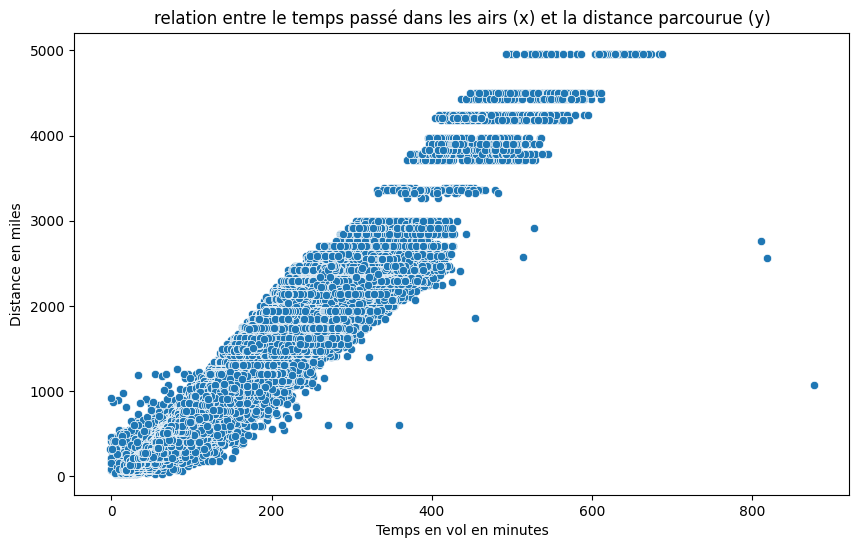

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



graph = pd.read_parquet("flights.parquet", engine="fastparquet")


plt.figure(figsize=(10,6))
sns.scatterplot(data=graph, x='AIR_TIME', y='DISTANCE')
plt.title("relation entre le temps passé dans les airs (x) et la distance parcourue (y)")
plt.xlabel("Temps en vol en minutes")
plt.ylabel("Distance en miles")
plt.show()


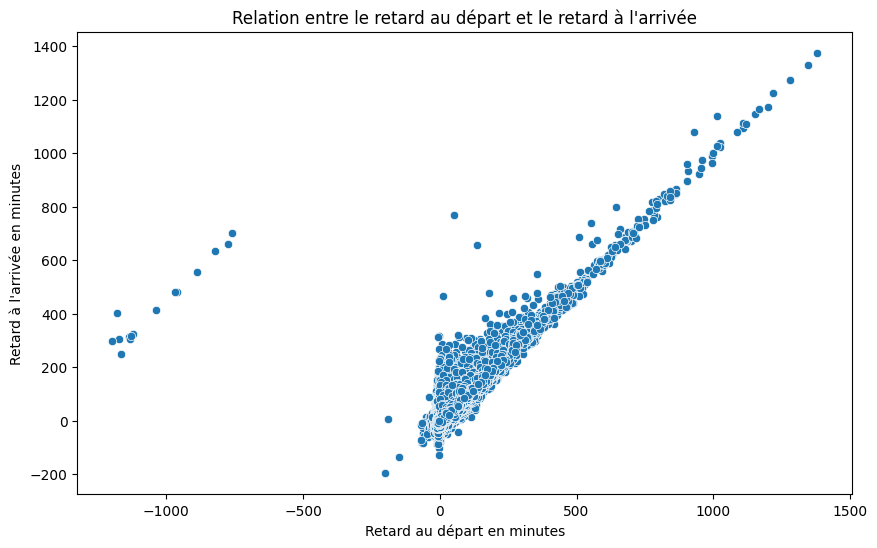

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=flights_df, x='DEP_DELAY', y='ARR_DELAY')
plt.title("Relation entre le retard au départ et le retard à l'arrivée")
plt.xlabel("Retard au départ en minutes")
plt.ylabel("Retard à l'arrivée en minutes")
plt.show()


### **Conclusions**

- plus un vol parcourt de *distance*, plus il passe de *temps dans les airs*,cela aussi dépend des conditions de vols et de l'avion,qu'il faut aussi prendre en paramètre  
- Si un avion prend du *retard* au décollage , il affectera son arrivé,mais parfois,certains vols arrivent à rattraper ce retard
